
 PART 1: DATA LOADING
File loaded successfully from:
  C:\Users\HP\OneDrive\Desktop\DS\csv\bank.csv

Shape of dataset : 11162 rows x 17 columns

First 5 rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5  

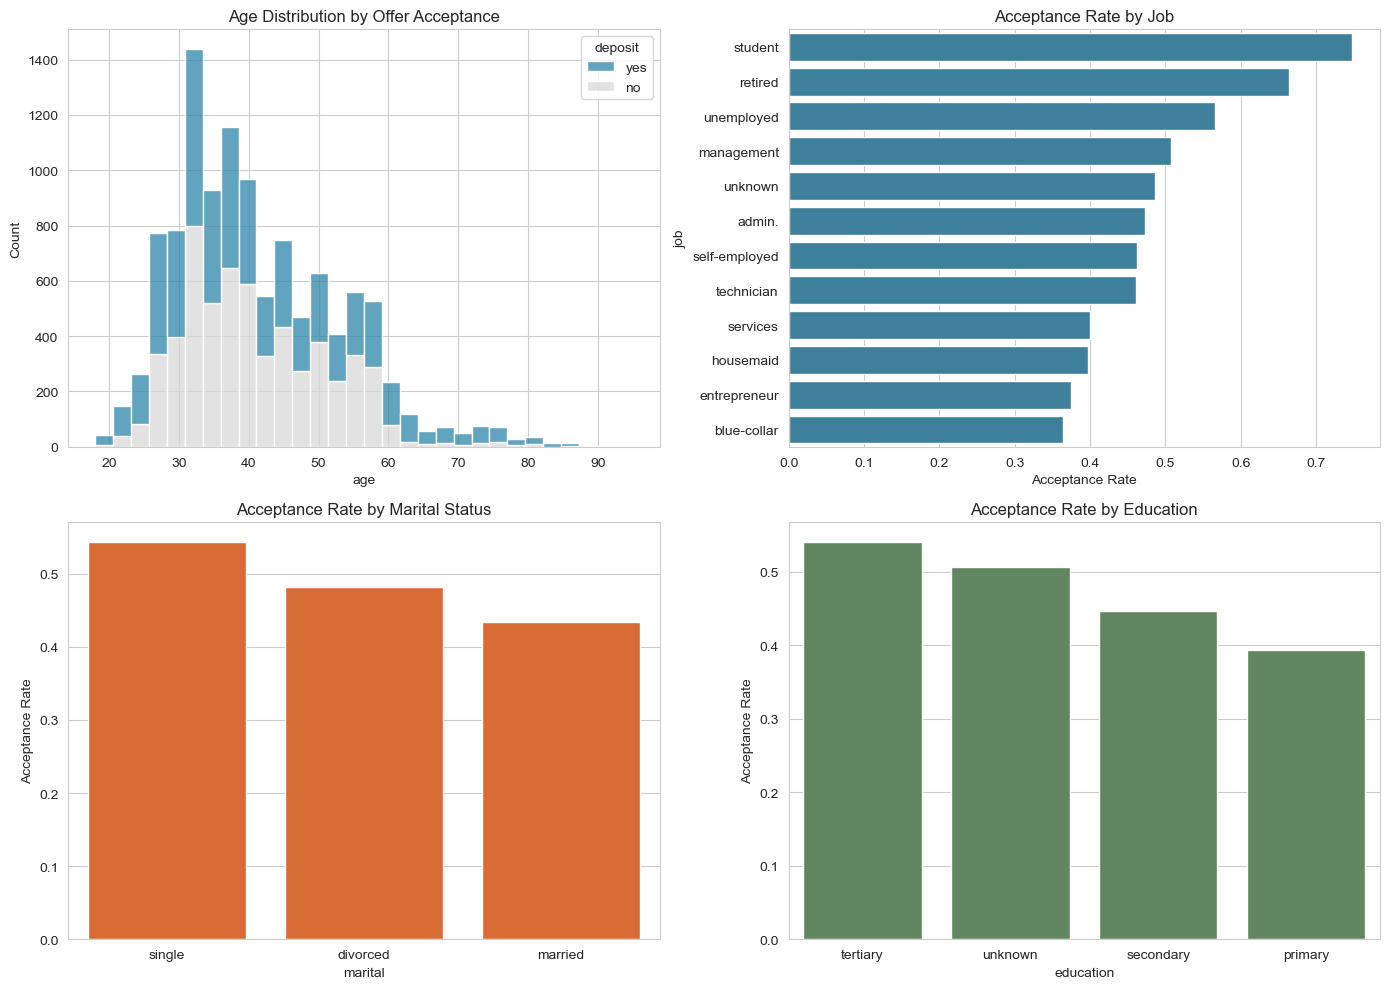

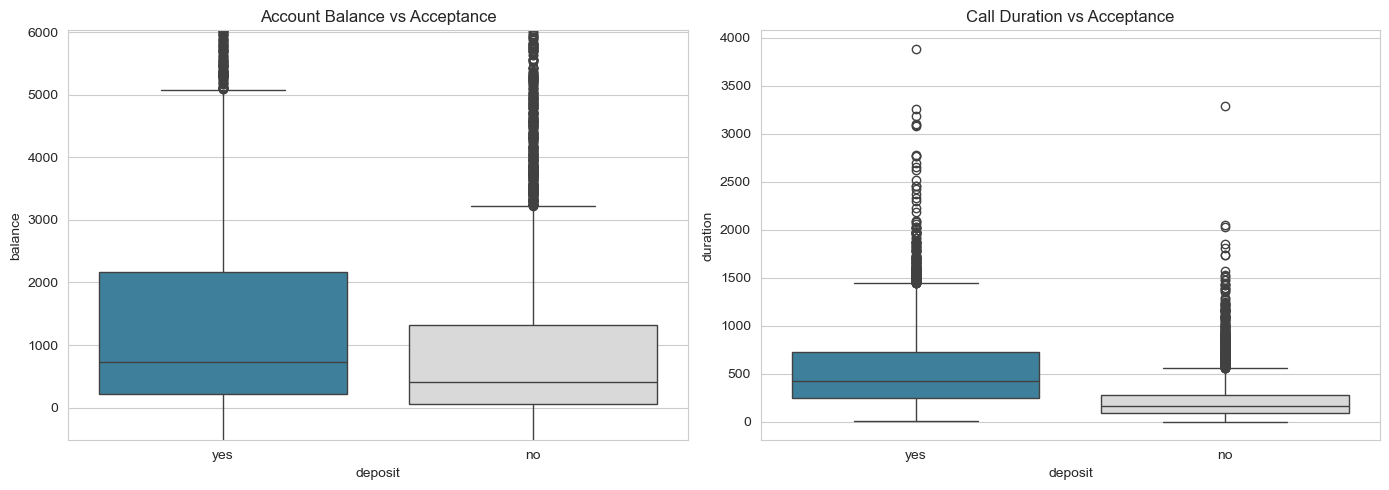


Key exploration findings:
  - Acceptance rate by job (top 3)      : {'student': 0.7472222222222222, 'retired': 0.6632390745501285, 'unemployed': 0.5658263305322129}
  - Acceptance rate by marital status   : {'single': 0.5434906196702672, 'divorced': 0.48105181747873166, 'married': 0.4337899543378995}
  - Acceptance rate by education        : {'tertiary': 0.5410680401192736, 'unknown': 0.5070422535211268, 'secondary': 0.44740686632578525, 'primary': 0.394}
  - Mean balance  (yes vs no)           : {'no': 1280.2271411544355, 'yes': 1804.2679145396105}
  - Mean call duration (yes vs no)      : {'no': 223.130257108803, 'yes': 537.2945736434109}

 PART 3: DATA PREPROCESSING
Encoding 9 categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Training set size : 8371 rows
Test set size     : 2791 rows
Feature count     : 16

 PART 4: MODEL TRAINING
Training Logistic Regression...
  -> Logistic Regression trained.
Training Decision Tr

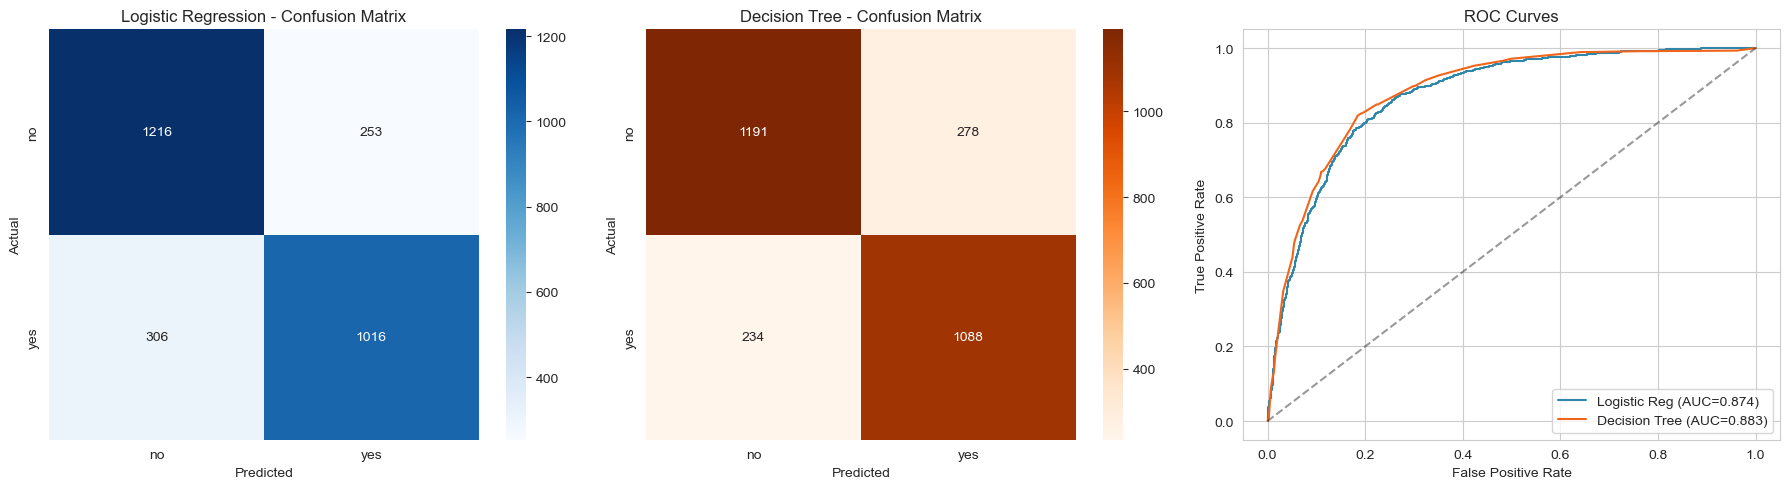


 PART 6: FEATURE IMPORTANCE ANALYSIS
Logistic Regression coefficients (standardized, sorted):
duration     1.708179
pdays        0.346186
previous     0.274760
poutcome     0.190626
education    0.177318
balance      0.133413
marital      0.114140
month        0.076734
age          0.073722
job          0.047419
default     -0.052086
day         -0.068425
loan        -0.274776
campaign    -0.361692
housing     -0.507123
contact     -0.531289
dtype: float64

Decision Tree feature importances (sorted):
duration     0.584425
contact      0.129218
pdays        0.089166
housing      0.062639
month        0.056233
poutcome     0.044638
balance      0.018762
age          0.004857
campaign     0.004481
day          0.002700
previous     0.001850
job          0.000577
education    0.000456
marital      0.000000
default      0.000000
loan         0.000000
dtype: float64


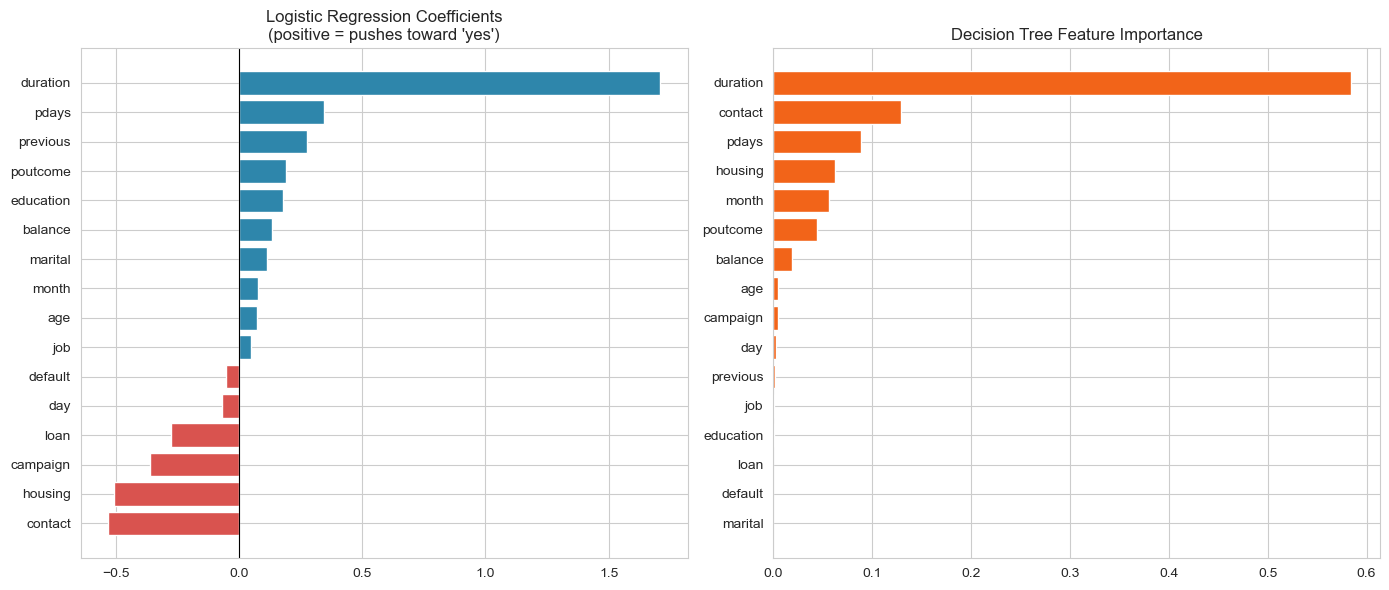


 PART 7: BUSINESS INSIGHT EXTRACTION
1. Overall acceptance rate            : 47.4%
2. Best job segments                  : {'student': 0.7472222222222222, 'retired': 0.6632390745501285, 'unemployed': 0.5658263305322129}
3. Best marital status segment        : single (54.3%)
4. Best education segment              : tertiary (54.1%)
5. Avg call duration  -- yes vs no     : {'no': 223.130257108803, 'yes': 537.2945736434109}
6. Avg account balance -- yes vs no    : {'no': 1280.2271411544355, 'yes': 1804.2679145396105}
7. Acceptance by prior outcome         : {'failure': 0.503257328990228, 'other': 0.5716945996275605, 'success': 0.9131652661064426, 'unknown': 0.40667787653134757}

SUMMARY OF RECOMMENDATIONS
---------------------------------------------------------------------------
  - Call duration is the single strongest predictor of acceptance -- agents
    should aim for longer, higher-quality conversations rather than rushing
    through scripted calls.
  - Customers who accepted a pr

In [7]:
"""
================================================================================
 TASK 5: PERSONAL LOAN / MARKETING OFFER ACCEPTANCE PREDICTION
================================================================================
 Dataset : Bank Marketing Dataset (UCI Machine Learning Repository)
 Path    : C:\\Users\\HP\\OneDrive\\Desktop\\DS\\bank.csv

 NOTE ON THE TARGET COLUMN
 --------------------------------------------------------------------------
 This file is the UCI "Bank Marketing" dataset. Its label column is
 `deposit` (yes/no) -- whether the customer accepted the bank's marketing
 offer (a term deposit) after being contacted. The `loan` column is just
 an existing customer attribute (already holds a personal loan or not),
 NOT the prediction target. Throughout this script, "accepted the offer"
 means deposit == 'yes'.

 WHAT THIS SCRIPT DOES
 --------------------------------------------------------------------------
   PART 1  Data Loading
   PART 2  Data Exploration (age, job, marital status, etc.)
   PART 3  Data Preprocessing (encoding, train/test split)
   PART 4  Model Training (Logistic Regression + Decision Tree)
   PART 5  Model Evaluation (accuracy, ROC-AUC, confusion matrix)
   PART 6  Feature Importance Analysis
   PART 7  Business Insight Extraction

 OUTPUT
 --------------------------------------------------------------------------
 Charts are saved as PNG files in the same folder as this script:
   01_exploration_overview.png
   02_balance_duration.png
   03_model_evaluation.png
   04_feature_importance.png
================================================================================
"""

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

sns.set_style("whitegrid")

# --------------------------------------------------------------------------
# CONFIG -- update this path if your file lives somewhere else
# --------------------------------------------------------------------------
DATA_PATH = r"C:\Users\HP\OneDrive\Desktop\DS\csv\bank.csv"
OUTPUT_DIR = os.getcwd()


def print_header(title: str) -> None:
    """Prints a clean, professional section banner to the console."""
    bar = "=" * 80
    print(f"\n{bar}\n {title}\n{bar}")


# ==========================================================================
# PART 1: DATA LOADING
# ==========================================================================
print_header("PART 1: DATA LOADING")

df = pd.read_csv(DATA_PATH)

print(f"File loaded successfully from:\n  {DATA_PATH}\n")
print(f"Shape of dataset : {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())


# ==========================================================================
# PART 2: DATA EXPLORATION
# ==========================================================================
print_header("PART 2: DATA EXPLORATION")

print("Summary statistics (numeric columns):")
print(df.describe())

print("\nTarget distribution (deposit -- did the customer accept the offer?):")
print(df["deposit"].value_counts())
overall_rate = (df["deposit"] == "yes").mean()
print(f"\nOverall acceptance rate: {overall_rate:.1%}")

# --- Chart 1: Age / Job / Marital / Education overview -------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x="age", hue="deposit", multiple="stack", bins=30,
             ax=axes[0, 0], palette={"yes": "#2E86AB", "no": "#D9D9D9"})
axes[0, 0].set_title("Age Distribution by Offer Acceptance")

job_rate = df.groupby("job")["deposit"].apply(lambda x: (x == "yes").mean()).sort_values(ascending=False)
sns.barplot(x=job_rate.values, y=job_rate.index, ax=axes[0, 1], color="#2E86AB")
axes[0, 1].set_title("Acceptance Rate by Job")
axes[0, 1].set_xlabel("Acceptance Rate")

marital_rate = df.groupby("marital")["deposit"].apply(lambda x: (x == "yes").mean()).sort_values(ascending=False)
sns.barplot(x=marital_rate.index, y=marital_rate.values, ax=axes[1, 0], color="#F26419")
axes[1, 0].set_title("Acceptance Rate by Marital Status")
axes[1, 0].set_ylabel("Acceptance Rate")

edu_rate = df.groupby("education")["deposit"].apply(lambda x: (x == "yes").mean()).sort_values(ascending=False)
sns.barplot(x=edu_rate.index, y=edu_rate.values, ax=axes[1, 1], color="#5B8C5A")
axes[1, 1].set_title("Acceptance Rate by Education")
axes[1, 1].set_ylabel("Acceptance Rate")

plt.tight_layout()
plt.show()
# --- Chart 2: Balance / Duration vs acceptance ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="deposit", y="balance", hue="deposit", ax=axes[0],
            palette={"yes": "#2E86AB", "no": "#D9D9D9"}, legend=False)
axes[0].set_title("Account Balance vs Acceptance")
axes[0].set_ylim(df["balance"].quantile(0.01), df["balance"].quantile(0.95))

sns.boxplot(data=df, x="deposit", y="duration", hue="deposit", ax=axes[1],
            palette={"yes": "#2E86AB", "no": "#D9D9D9"}, legend=False)
axes[1].set_title("Call Duration vs Acceptance")

plt.tight_layout()
plt.show()

print("\nKey exploration findings:")
print(f"  - Acceptance rate by job (top 3)      : {job_rate.head(3).to_dict()}")
print(f"  - Acceptance rate by marital status   : {marital_rate.to_dict()}")
print(f"  - Acceptance rate by education        : {edu_rate.to_dict()}")
print(f"  - Mean balance  (yes vs no)           : {df.groupby('deposit')['balance'].mean().to_dict()}")
print(f"  - Mean call duration (yes vs no)      : {df.groupby('deposit')['duration'].mean().to_dict()}")


# ==========================================================================
# PART 3: DATA PREPROCESSING
# ==========================================================================
print_header("PART 3: DATA PREPROCESSING")

data = df.copy()
target = "deposit"
data[target] = data[target].map({"yes": 1, "no": 0})

categorical_cols = data.select_dtypes(include="object").columns.tolist()
print(f"Encoding {len(categorical_cols)} categorical columns: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTraining set size : {X_train.shape[0]} rows")
print(f"Test set size     : {X_test.shape[0]} rows")
print(f"Feature count     : {X_train.shape[1]}")


# ==========================================================================
# PART 4: MODEL TRAINING
# ==========================================================================
print_header("PART 4: MODEL TRAINING")

# --- Model 1: Logistic Regression (needs scaled features) ---------------
print("Training Logistic Regression...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("  -> Logistic Regression trained.")

# --- Model 2: Decision Tree -----------------------------------------------
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced")
dt_model.fit(X_train, y_train)
print("  -> Decision Tree trained.")


# ==========================================================================
# PART 5: MODEL EVALUATION
# ==========================================================================
print_header("PART 5: MODEL EVALUATION")

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("--- Logistic Regression ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=["no", "yes"]))

print("--- Decision Tree ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=["no", "yes"]))

# --- Chart 3: Confusion matrices + ROC curves -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["no", "yes"], yticklabels=["no", "yes"])
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=["no", "yes"], yticklabels=["no", "yes"])
axes[1].set_title("Decision Tree - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
axes[2].plot(fpr_lr, tpr_lr, label=f"Logistic Reg (AUC={roc_auc_score(y_test, y_proba_lr):.3f})", color="#2E86AB")
axes[2].plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={roc_auc_score(y_test, y_proba_dt):.3f})", color="#F26419")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[2].set_title("ROC Curves")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
plt.tight_layout()
plt.show()
# ==========================================================================
# PART 6: FEATURE IMPORTANCE ANALYSIS
# ==========================================================================
print_header("PART 6: FEATURE IMPORTANCE ANALYSIS")

coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(ascending=False)
print("Logistic Regression coefficients (standardized, sorted):")
print(coefs)

importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nDecision Tree feature importances (sorted):")
print(importances)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

coefs_sorted = coefs.sort_values()
axes[0].barh(coefs_sorted.index, coefs_sorted.values,
             color=["#D9534F" if v < 0 else "#2E86AB" for v in coefs_sorted.values])
axes[0].set_title("Logistic Regression Coefficients\n(positive = pushes toward 'yes')")
axes[0].axvline(0, color="black", linewidth=0.8)

importances_sorted = importances.sort_values()
axes[1].barh(importances_sorted.index, importances_sorted.values, color="#F26419")
axes[1].set_title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()

# ==========================================================================
# PART 7: BUSINESS INSIGHT EXTRACTION
# ==========================================================================
print_header("PART 7: BUSINESS INSIGHT EXTRACTION")

poutcome_rate = df.groupby("poutcome")["deposit"].apply(lambda x: (x == "yes").mean())

print(f"1. Overall acceptance rate            : {overall_rate:.1%}")
print(f"2. Best job segments                  : {job_rate.head(3).to_dict()}")
print(f"3. Best marital status segment        : {marital_rate.idxmax()} ({marital_rate.max():.1%})")
print(f"4. Best education segment              : {edu_rate.idxmax()} ({edu_rate.max():.1%})")
print(f"5. Avg call duration  -- yes vs no     : {df.groupby('deposit')['duration'].mean().to_dict()}")
print(f"6. Avg account balance -- yes vs no    : {df.groupby('deposit')['balance'].mean().to_dict()}")
print(f"7. Acceptance by prior outcome         : {poutcome_rate.to_dict()}")

print("""
SUMMARY OF RECOMMENDATIONS
---------------------------------------------------------------------------
  - Call duration is the single strongest predictor of acceptance -- agents
    should aim for longer, higher-quality conversations rather than rushing
    through scripted calls.
  - Customers who accepted a previous campaign convert ~91% of the time --
    prioritize re-contacting past "yes" customers.
  - Students, retirees, and unemployed customers convert at the highest
    rates; married, lower-education, blue-collar segments convert least.
  - Customers with an existing housing loan convert less -- likely lower
    available cash flow.
  - Excessive repeat contact (`campaign`) and certain `contact` channels
    correlate with LOWER acceptance -- fewer, well-targeted contacts beat
    high-volume outreach.
---------------------------------------------------------------------------
""")
